In [21]:
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
zip_path = "dataset.zip"
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [27]:
import os

print(os.path.exists("dataset"))
print(os.listdir("dataset") if os.path.exists("dataset") else "No dataset folder")

True
['dataset']


In [28]:
dataset_path = "dataset/dataset/faces"

In [30]:
from google.colab import files

uploaded = files.upload()

Saving dataset.zip to dataset (1).zip


In [25]:
print(os.listdir(extract_path))

['dataset']


In [24]:
import os

for root, dirs, files in os.walk("."):
    print("ROOT:", root)
    print("FOLDERS:", dirs[:10])
    print("FILES:", files[:10])
    print("="*60)

ROOT: .
FOLDERS: ['.config', 'drive', 'dataset', 'sample_data']
FILES: ['dataset.zip']
ROOT: ./.config
FOLDERS: ['configurations', 'logs']
FILES: ['default_configs.db', '.last_update_check.json', '.last_survey_prompt.yaml', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', 'active_config', '.last_opt_in_prompt.yaml', 'gce', 'config_sentinel']
ROOT: ./.config/configurations
FOLDERS: []
FILES: ['config_default']
ROOT: ./.config/logs
FOLDERS: ['2026.05.12']
FILES: []
ROOT: ./.config/logs/2026.05.12
FOLDERS: []
FILES: ['13.29.40.400999.log', '13.29.25.418951.log', '13.29.27.205677.log', '13.29.12.483949.log', '13.29.39.608616.log', '13.28.53.384927.log']
ROOT: ./drive
FOLDERS: ['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']
FILES: []
ROOT: ./drive/MyDrive
FOLDERS: ['Colab Notebooks', 'Saibaba ']
FILES: ['marks card', 'IMG-20240725-WA0054.jpg', 'IMG_20240819_131007.jpg', '1725205185301.jpg', 'IMG_20240903_150447 (1).jpg', 'IMG_20240903_150447.jpg', 'IMG-2024

In [33]:
image_size = (100, 100)

X = []
y = []

dataset_path = "dataset/dataset/faces"

for person_name in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person_name)

    if os.path.isdir(person_path):

        for image_name in os.listdir(person_path):

            image_path = os.path.join(person_path, image_name)

            img = cv2.imread(image_path)

            if img is None:
                continue

            # Convert to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Resize image
            gray = cv2.resize(gray, image_size)

            # Flatten image into vector
            face_vector = gray.flatten()

            X.append(face_vector)
            y.append(person_name)

X = np.array(X)
y = np.array(y)

print("Total Images:", len(X))
print("Image shape:", X.shape)
print("Labels shape:", y.shape)

Total Images: 450
Image shape: (450, 10000)
Labels shape: (450,)


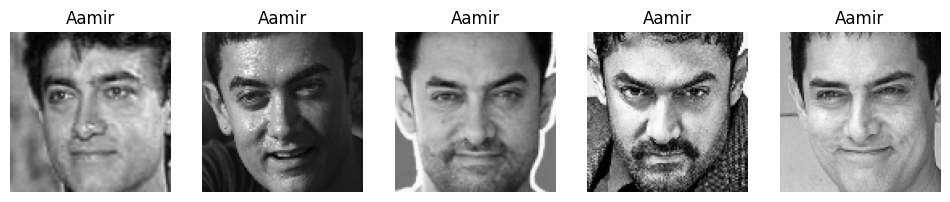

In [34]:
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X[i].reshape(100,100), cmap='gray')
    plt.title(y[i])
    plt.axis('off')

plt.show()

In [35]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:")
print(encoder.classes_)

Classes:
['Aamir' 'Ajay' 'Akshay' 'Alia' 'Amitabh' 'Deepika' 'Disha' 'Farhan'
 'Ileana']


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.40,
    random_state=42,
    stratify=y_encoded
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (270, 10000)
Testing shape: (180, 10000)


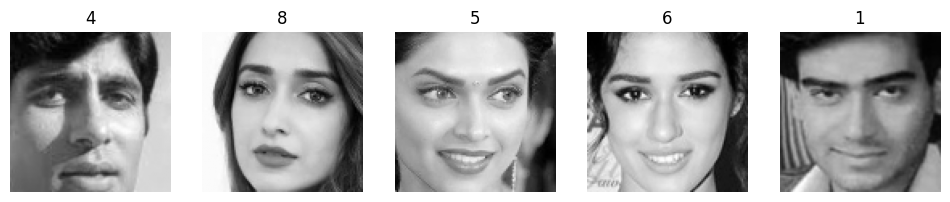

In [37]:
plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(100,100), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [39]:
mean_face = np.mean(X_train, axis=0)

print("Mean face shape:", mean_face.shape)

Mean face shape: (10000,)


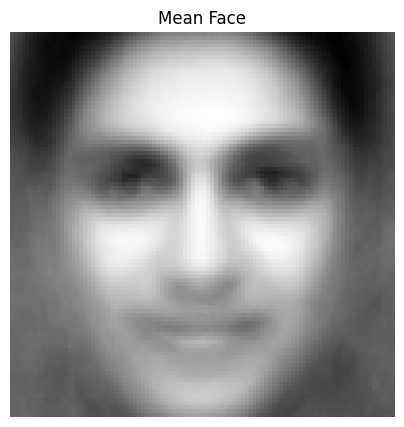

In [40]:
plt.figure(figsize=(5,5))
plt.imshow(mean_face.reshape(100,100), cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()

In [41]:
X_train_centered = X_train - mean_face

print("Centered training data shape:")
print(X_train_centered.shape)

Centered training data shape:
(270, 10000)


In [42]:
cov_matrix = np.dot(X_train_centered, X_train_centered.T)

print("Covariance matrix shape:")
print(cov_matrix.shape)

Covariance matrix shape:
(270, 270)


In [43]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

print("Eigenvalues sorted successfully")

Eigenvalues sorted successfully


In [44]:
k = 50

top_k_vectors = eigenvectors[:, :k]

print("Top k eigenvectors shape:")
print(top_k_vectors.shape)

Top k eigenvectors shape:
(270, 50)


In [45]:
eigenfaces = np.dot(top_k_vectors.T, X_train_centered)

print("Eigenfaces shape:")
print(eigenfaces.shape)

Eigenfaces shape:
(50, 10000)


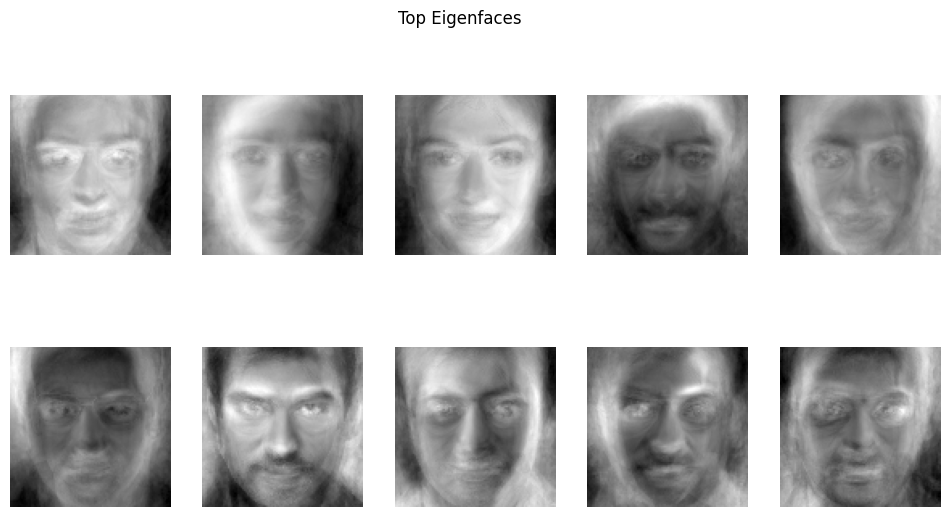

In [46]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(
        eigenfaces[i].real.reshape(100,100),
        cmap='gray'
    )

    plt.axis('off')

plt.suptitle("Top Eigenfaces")
plt.show()

In [47]:
train_signatures = np.dot(
    X_train_centered,
    eigenfaces.T
)

print("Train signatures shape:")
print(train_signatures.shape)

Train signatures shape:
(270, 50)


In [48]:
X_test_centered = X_test - mean_face

print(X_test_centered.shape)

(180, 10000)


In [49]:
test_signatures = np.dot(
    X_test_centered,
    eigenfaces.T
)

print("Test signatures shape:")
print(test_signatures.shape)

Test signatures shape:
(180, 50)


In [50]:
num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(
    y_train,
    num_classes=num_classes
)

y_test_cat = to_categorical(
    y_test,
    num_classes=num_classes
)

print(y_train_cat.shape)

(270, 9)


In [51]:
model = Sequential()

model.add(Dense(
    64,
    activation='relu',
    input_shape=(k,)
))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dense(
    num_classes,
    activation='softmax'
))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,641 (22.04 KB)

 Trainable params: 5,641 (22.04 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
history = model.fit(
    train_signatures,
    y_train_cat,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30


 1/14 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.0625 - loss: 19845176.0000

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.1111 - loss: 15075916.0000 - val_accuracy: 0.1481 - val_loss: 10061273.0000
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1574 - loss: 7915408.5000 - val_accuracy: 0.1667 - val_loss: 7920051.0000
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2546 - loss: 5031485.5000 - val_accuracy: 0.1667 - val_loss: 6979437.0000
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3333 - loss: 3649124.7500 - val_accuracy: 0.1296 - val_loss: 6046355.0000
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3611 - loss: 2791020.7500 - val_accuracy: 0.1481 - val_loss: 5375973.5000
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4491 - loss: 2088203.2500 - val_accuracy: 0.1852 - val_loss: 4894059.0000
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4769 - loss: 1674617.7500 - val_accuracy: 0.1852 - val_loss: 4513195.0000
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7

In [54]:
loss, accuracy = model.evaluate(
    test_signatures,
    y_test_cat
)

print("Test Accuracy:", accuracy * 100)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4611 - loss: 2219886.5000 
Test Accuracy: 46.11110985279083


1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


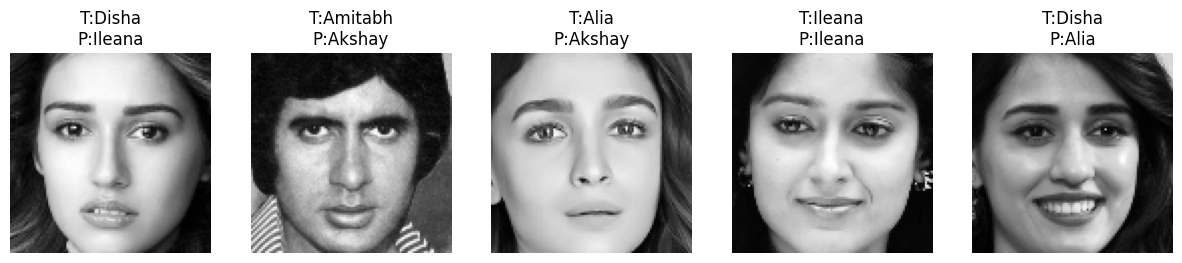

In [55]:
predictions = model.predict(test_signatures)

predicted_labels = np.argmax(
    predictions,
    axis=1
)

plt.figure(figsize=(15,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        X_test[i].reshape(100,100),
        cmap='gray'
    )

    true_name = encoder.inverse_transform(
        [y_test[i]]
    )[0]

    pred_name = encoder.inverse_transform(
        [predicted_labels[i]]
    )[0]

    plt.title(
        f"T:{true_name}\nP:{pred_name}"
    )

    plt.axis('off')

plt.show()

In [56]:
k_values = [5, 10, 20, 30, 40, 50]

accuracies = []

for k_temp in k_values:

    top_vectors = eigenvectors[:, :k_temp]

    eigenfaces_temp = np.dot(
        top_vectors.T,
        X_train_centered
    )

    train_sig = np.dot(
        X_train_centered,
        eigenfaces_temp.T
    )

    test_sig = np.dot(
        X_test_centered,
        eigenfaces_temp.T
    )

    model_temp = Sequential()

    model_temp.add(Dense(
        64,
        activation='relu',
        input_shape=(k_temp,)
    ))

    model_temp.add(Dense(
        num_classes,
        activation='softmax'
    ))

    model_temp.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model_temp.fit(
        train_sig,
        y_train_cat,
        epochs=20,
        verbose=0
    )

    _, acc = model_temp.evaluate(
        test_sig,
        y_test_cat,
        verbose=0
    )

    accuracies.append(acc * 100)

print(accuracies)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[29.444444179534912, 32.22222328186035, 43.33333373069763, 36.11111044883728, 46.11110985279083, 46.11110985279083]


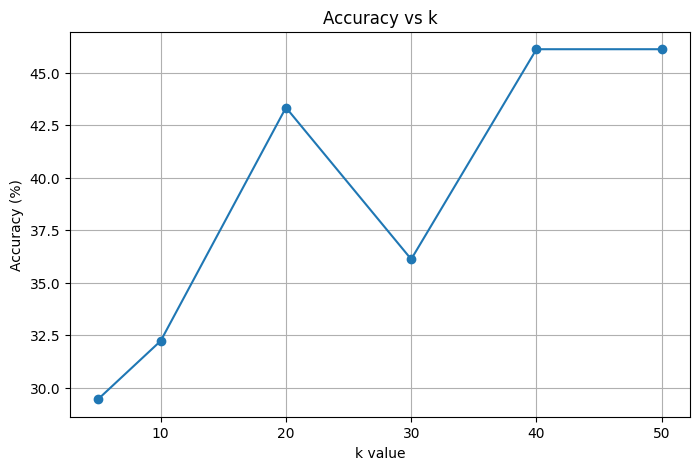

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("k value")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs k")

plt.grid(True)

plt.show()

In [58]:
sample = test_signatures[0]

prediction = model.predict(
    sample.reshape(1,-1)
)

confidence = np.max(prediction)

predicted_class = np.argmax(
    prediction
)

if confidence < 0.70:
    print("Not Enrolled Person")
else:
    print(
        "Recognized:",
        encoder.inverse_transform(
            [predicted_class]
        )[0]
    )

print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Recognized: Ileana
Confidence: 1.0


In [59]:
if confidence < 0.70:
    print("Not Enrolled Person")

In [60]:
loss, accuracy = model.evaluate(
    test_signatures,
    y_test_cat
)

print("Final Accuracy:", round(accuracy*100,2), "%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4611 - loss: 2219886.5000
Final Accuracy: 46.11 %
